$\textbf{Giải bài toán Thế vuông hữu hạn}$

In [151]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('sci.mplstyle')

$\textbf{Tích phân số bằng Monte Carlo}$ (Định lý giá trị trung bình):    
Thay vì đo diện tích từng hình thang nhỏ, ta sẽ "chấm" ngẫu nhiên hàng chục nghìn điểm trên trục $x$. Ta tính chiều cao của đồ thị tại các điểm ngẫu nhiên đó, lấy trung bình cộng để ra được một chiều cao trung bình. Cuối cùng, lấy chiều cao trung bình này nhân với tổng chiều rộng của không gian là ra diện tích.
$$
I \approx (b - a) \times \frac{1}{N} \sum_{i=1}^{N} f(x_i)
$$
Trong đó $x_i$ là các điểm được bốc ngẫu nhiên trong khoảng $[a, b]$, và $N$ là tổng số điểm bốc 

In [152]:
def Tichphan_monte_carlo(func, a, b, N=100000):
    x_random = np.random.uniform(a, b, N)
    y_random = func(x_random)
    y_mean = np.mean(y_random)
    area = (b - a) * y_mean
    return area

$\textbf{Hàm sóng}$ $(V_0<0,E<0)$
$$
\psi(x) = 
\begin{cases} 
B e^{\kappa x} & \text{khi } x < -a \text{ (Vùng 1: Ngoài giếng, bên trái)} \\ 
C \cos(lx) & \text{khi } -a \le x \le a \text{ (Vùng 2: Trong giếng)} \\ 
F e^{-\kappa x} & \text{khi } x > a \text{ (Vùng 3: Ngoài giếng, bên phải)} 
\end{cases}
$$
Đặt $C=1$:  
Tại $x=-a$ thì $B = \cos(la)e^{ka}$.  
Tại $x=a$ thì $F = \cos(la)e^{-ka}$ 

Hàm sóng (chưa chuẩn hóa):
$$\psi(x) = \begin{cases} 
\cos(la) e^{\kappa(x+a)} & \text{khi } x < -a \\ 
\cos(lx) & \text{khi } -a \le x \le a \\ 
\cos(la) e^{-\kappa(x-a)} & \text{khi } x > a 
\end{cases}$$



In [153]:
def psi_unnormalized(x, z, z0, a):
    l = z / a
    kappa = np.sqrt(z0**2 - z**2) / a
    return np.where(x < -a, np.cos(l*a) * np.exp(kappa*(x+a)),
           np.where(x > a,  np.cos(l*a) * np.exp(-kappa*(x-a)),
                            np.cos(l*x)))

$\textbf{Công thức tính Z0}$:
$$
z_0 = \frac{a}{\hbar} \sqrt{2mV_0} = a \sqrt{\frac{2m}{\hbar^2}V_0}
$$
Với:
- a: $fm$
- $\frac{2m}{\hbar^2}$ = 0.0483 $Mev^{-1} .fm^-1$
- $V_0$: $Mev$

$\textbf{Thông số và nghiệm Z}$

In [154]:
# 1. Các thông số đầu vào chung
a = 10  # fm
V0 = 10  # MeV
z0 = a*np.sqrt(V0*0.0483) # tính Z0


$\textbf{Giải phương trình}$ $\tan(z)=\sqrt{(z_0/z)^2-1}$ (plot)

<>:57: SyntaxWarning: invalid escape sequence '\p'
<>:58: SyntaxWarning: invalid escape sequence '\p'
<>:59: SyntaxWarning: invalid escape sequence '\p'
<>:57: SyntaxWarning: invalid escape sequence '\p'
<>:58: SyntaxWarning: invalid escape sequence '\p'
<>:59: SyntaxWarning: invalid escape sequence '\p'
C:\Users\ntqua\AppData\Local\Temp\ipykernel_25704\2399159292.py:57: SyntaxWarning: invalid escape sequence '\p'
  {"z": z1, "z0": z0, "color": "b", "label": f"$\psi_1:E_1$"},
C:\Users\ntqua\AppData\Local\Temp\ipykernel_25704\2399159292.py:58: SyntaxWarning: invalid escape sequence '\p'
  {"z": z2, "z0": z0, "color": "r", "label": f"$\psi_2:E_2$"},
C:\Users\ntqua\AppData\Local\Temp\ipykernel_25704\2399159292.py:59: SyntaxWarning: invalid escape sequence '\p'
  {"z": z3, "z0": z0, "color": "g", "label": f"$\psi_3:E_3$"}
C:\Users\ntqua\AppData\Local\Temp\ipykernel_25704\2399159292.py:6: RuntimeWarning: invalid value encountered in sqrt
  y_sqrt = np.sqrt((z0/x)**2 - 1)


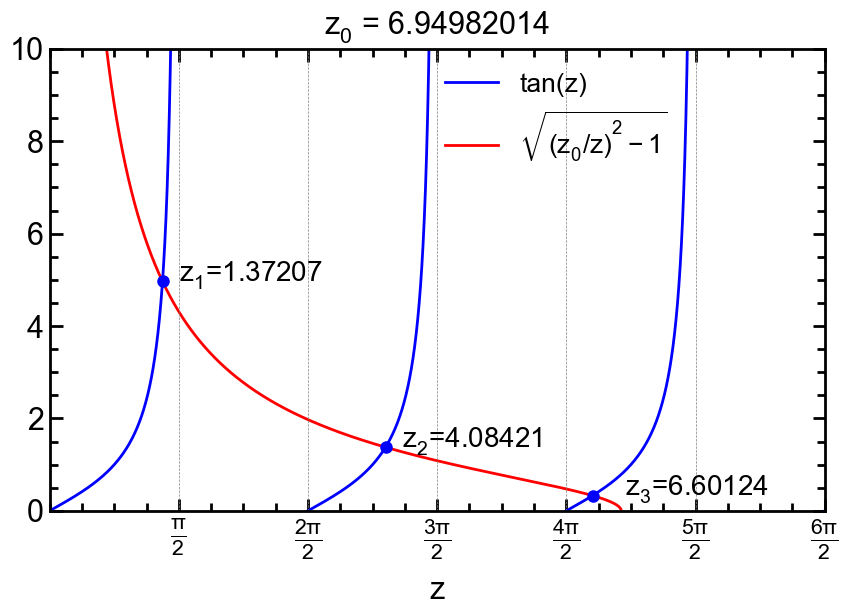

In [155]:
x = np.linspace(0.01, 10, 100000)# Đổi số 0 thành 0.01 để tránh chia cho 0
y_tan = np.tan(x)
# Chỗ nào bị rớt xuống âm vô cực (độ chênh lệch < 0), ta bắt máy tính xóa điểm đó đi (gán bằng np.nan)
y_tan[:-1][np.diff(y_tan) < 0] = np.nan

y_sqrt = np.sqrt((z0/x)**2 - 1)
plt.figure(figsize=(10, 6))
plt.plot(x, y_tan, label=r'tan(z)', color = 'b')
plt.plot(x, y_sqrt, label=r"$\sqrt{(z_0/z)^2-1}$", color = 'r')
plt.title(f'$z_0$ = {z0:.8f}')
plt.xlabel('z')

x_ticks = np.arange(np.pi/2, 20 + np.pi/2, np.pi/2)
x_labels = []
for i in range(1, len(x_ticks) + 1):
    if i == 1:
        x_labels.append(r'$\frac{\pi}{2}$')
    else:
        x_labels.append(rf'$\frac{{{i}\pi}}{{2}}$')

plt.xticks(x_ticks, x_labels)

for xt in x_ticks:
     plt.axvline(xt, color='gray', lw=0.5, ls='--')
plt.axhline(0, color='gray', lw=0.5, ls='--')
#Dat gioi han truc
x_lim = 6 * np.pi / 2
plt.xlim(0, x_lim)
plt.tick_params(direction='in')
plt.ylim(0, 10) 
#plt.grid()

#Toa do legend
plt.legend(loc='upper left', bbox_to_anchor=(0.48,1))

###########Nghiem######
z1 = 1.3720661149615885
z2 = 4.0842110751191516
z3 = 6.6012449588901330


#### mark nghiem######
plt.plot(z1, np.tan(z1), 'bo', markersize=8)
plt.text(z1+0.2, np.tan(z1), f'$z_1$={z1:.5f}', color='black', fontsize=20)

plt.plot(z2, np.tan(z2), 'bo', markersize=8)
plt.text(z2+0.2, np.tan(z2), f'$z_2$={z2:.5f}', color='black', fontsize=20)

plt.plot(z3, np.tan(z3), 'bo', markersize=8)
plt.text(z3+0.4, np.tan(z3), f'$z_3$={z3:.5f}', color='black', fontsize=20)
plt.savefig("NghiemZ_V10_a10.pdf", dpi=300, bbox_inches='tight')
plt.show()


################
states = [
    {"z": z1, "z0": z0, "color": "b", "label": f"$\psi_1:E_1$"},
    {"z": z2, "z0": z0, "color": "r", "label": f"$\psi_2:E_2$"},
    {"z": z3, "z0": z0, "color": "g", "label": f"$\psi_3:E_3$"}
]

Tính năng lượng
$$
E = \frac{\hbar^2(z^2-z_0^2)}{2ma^2} \quad \text{(Mev)}
$$
Hàm sóng chuẩn hóa:
$$
\psi_{\text{Chuẩn hóa}} = \frac{\psi_{\text{Chưa chuẩn hóa}}}{N}
$$
Với $N = \sqrt{\int_{-\infty}^{+\infty} |\psi_{\text{Chưa chuẩn hóa}}|^2 dx}$

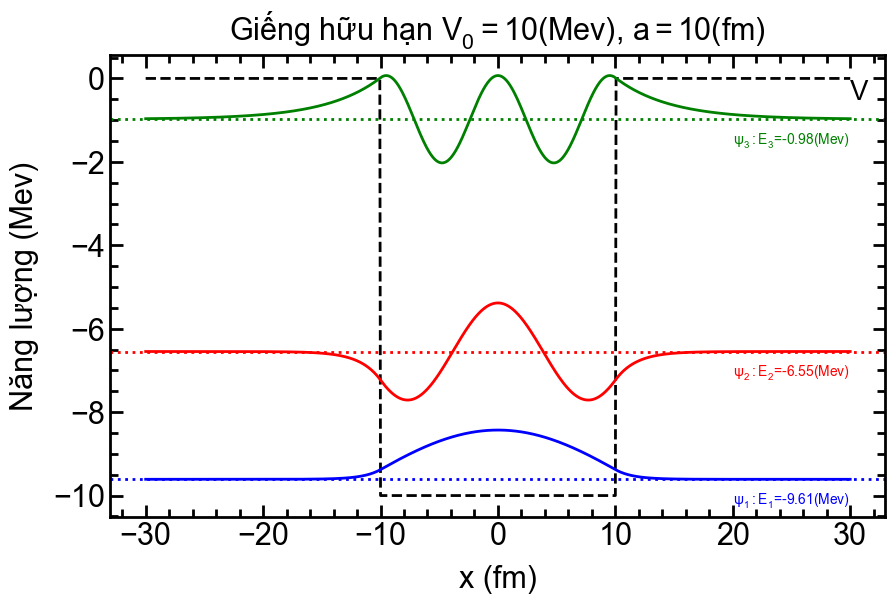

In [156]:
# Tạo mảng tọa độ x chung
x_start = -3 * a
x_end = 3 * a
x_vals = np.linspace(x_start, x_end, 1000)


plt.figure(figsize=(10, 6))

# Vẽ giếng thế chung
V_x = np.where((x_vals >= -a) & (x_vals <= a), -V0, 0)
plt.plot(x_vals, V_x , 'k--', label='Giếng thế V(x)')
plt.text(3*a, -V0*0.05, 'V', color='black', fontsize=20)
#Vòng lặp tính toán và vẽ cho từng trạng thái
for state in states:
    z_val = state["z"]
    z0_val = state["z0"]

    # Chuyển sang năng lượng
    E_val = (z_val**2-z0_val**2)/(0.0483*a**2)

    # Tính hàm sóng chưa chuẩn hóa
    psi_vals = psi_unnormalized(x_vals, z_val, z0_val, a)
    
    # Dùng lambda để bọc hàm sóng lại thành một hàm chỉ có 1 biến x,
    # Lấy bình phương (**2) để tính xác suất
    pdf_func = lambda x: psi_unnormalized(x, z_val, z0_val, a)**2
    
    # Chuẩn hóa bằng Monte Carlo
    area_mc = Tichphan_monte_carlo(pdf_func, x_start, x_end, N=1000000)
    norm_constant = np.sqrt(area_mc)
    
    #hàm sóng đã chuẩn hóa
    psi_normalized = psi_vals / norm_constant
    
    # Vẽ lên đồ thị
    scale = V0*0.4
    plt.plot(x_vals, psi_normalized*scale+E_val, color=state["color"], label=state["label"])
    plt.axhline(E_val, color=state["color"], linestyle=':')
    plt.text(2*a, E_val-0.06*V0, state["label"]+f'={E_val:.2f}(Mev)', color=state["color"], fontsize=10)


plt.tick_params(direction='in')
# plt.axvline(-a, color='gray', linestyle=':')
# plt.axvline(a, color='gray', linestyle=':')
plt.xlabel('x (fm)')
plt.ylabel('Năng lượng (Mev)')
plt.title(f'Giếng hữu hạn $V_0={V0} (Mev)$, $a = {a} (fm)$')
#plt.legend(loc='upper right')
plt.savefig("Hamsong_V10_a10.pdf", dpi=300, bbox_inches='tight')
plt.show()
